# Basic Functions

## Parsing Data

In [1]:
from astroquery.vizier import Vizier
from astropy.table import join
from astropy.table import Table
import os
import warnings
from astropy.utils.metadata import MergeConflictWarning
import numpy as np
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker # to format ticks

In [2]:
def lotss_func(lotss_columns_parse, row_lim):
    lotss_filename = "J/A+A/678/A151"
    viz_lotss = Vizier(columns=lotss_columns_parse, row_limit=row_lim)
    viz_lotss.column_filters = {
        "PlateSDSS": ">0",
        "FiberSDSS": ">0",
        "MJDSDSS": ">0"
    } # non-empty plates, etc.
    lotss_data = viz_lotss.get_catalogs(lotss_filename) 
    return lotss_data[0]

def WISE_func(WISE_columns_parse, row_lim):
    viz_WISE = Vizier(columns=WISE_columns_parse, row_limit=row_lim)
    viz_WISE.column_filters = {
        "Plate": ">0",
        "Fiber": ">0",
        "MJD": ">0"
    } # non-empty plates, etc. 
    WISE_filename = "J/ApJ/859/11"
    WISE_data = viz_WISE.get_catalogs(WISE_filename) 

    # preparing for merge later
    WISE_data[1].rename_column('Plate', 'PlateSDSS')
    WISE_data[1].rename_column('MJD', 'MJDSDSS')
    WISE_data[1].rename_column('Fiber', 'FiberSDSS')
    
    return WISE_data[1]


def make_table(lotss_columns_parse, WISE_columns_parse, row_lim, timeout_viz):
    
    vizier_custom = Vizier(row_limit=-1, timeout=timeout_viz)

    LOTSS = lotss_func(lotss_columns_parse, row_lim)
    WISE = WISE_func(WISE_columns_parse, row_lim)

    warnings.filterwarnings('ignore', category=MergeConflictWarning)
    matched_table = join(LOTSS, WISE, keys=['PlateSDSS', 'MJDSDSS', 'FiberSDSS'], join_type='inner')
    
    print(f"Total sources in LoTSS: {len(LOTSS)}")
    print(f"Total sources in GSWLC-2: {len(WISE)}")
    print(f"Successfully matched sources: {len(matched_table)}")
    
    matched_table.write('mathced_draft.fits', format='fits', overwrite=True)

    return matched_table


def load_fits_table(file_path): # function to retrieve written fits file. 
    # 1. Load the table from your computer
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Couldn't find {file_path}. Did you save it yet?")
    matched_table = Table.read(file_path)
    print(f"Successfully loaded {len(matched_table)} sources from disk.")

    return matched_table

In [55]:
lotss_columns_parse = ['PlateSDSS', 'FiberSDSS', 'MJDSDSS', 'Ftot', 'zphot', 'logMass', 'Type', 'r50', 'CompSize']
WISE_columns_parse = ['Plate', 'Fiber', 'MJD', 'logSFR']


matched_draft = make_table(lotss_columns_parse, WISE_columns_parse, row_lim = 10e5, timeout_viz = 100000)

Total sources in LoTSS: 296921
Total sources in GSWLC-2: 361328
Successfully matched sources: 40476


In [3]:
matched_draft = load_fits_table("mathced_draft.fits")

Successfully loaded 40476 sources from disk.


In [4]:
def filter_nan_empty(matched_table): 
    is_valid = ~matched_table['logSFR'].mask & ~matched_table['logMass'].mask
    is_not_nan = ~np.isnan(matched_table['logSFR']) & ~np.isnan(matched_table['logMass'])
    clean_table = matched_table[is_valid & is_not_nan]
    
    print(f"Rows remaining after null-filtering: {len(clean_table)}")
    return clean_table

def flux_to_luminosity(clean_table):
    cosmo = FlatLambdaCDM(H0=67.8, Om0=0.308)
    z = clean_table['zphot'].filled(np.nan) 
    dist_m = cosmo.luminosity_distance(z).to(u.m).value # before we had cm**2, but change to m to cancel units
    
    alpha = -0.7
    k_corr = (1 + z)**(alpha - 1)
    flux_w_m2_hz = clean_table['Ftot'] * 1e-29
    luminosity = 4 * np.pi * (dist_m**2) * flux_w_m2_hz * k_corr
    clean_table['logL144'] = np.log10(luminosity)
    clean_table['logL144'].unit = u.dex(u.W / u.Hz)

#########################
#########################


def r50_to_radius(data): # Function written completely by GEMINI
    # 1. Setup cosmology from your notebook parameters
    cosmo = FlatLambdaCDM(H0=67.8, Om0=0.308)
    z = data['zphot'].filled(np.nan)
    
    # 2. Get the physical scale (kpc per arcsec) as a Quantity
    # cosmo.kpc_proper_per_arcmin returns a Quantity
    kpc_per_arcsec = cosmo.kpc_proper_per_arcmin(z).to(u.kpc / u.arcsec)
    
    # 3. Ensure the angular radius is treated as arcseconds
    # Using u.Quantity ensures we don't double-up units if they already exist[cite: 1]
    r50_angular = u.Quantity(data['r50'].filled(np.nan), u.arcsec)
    
    # 4. Multiply: (arcsec) * (kpc / arcsec) = kpc
    radius_kpc = r50_angular * kpc_per_arcsec
    
    # 5. Convert to cm and return just the numeric value
    return radius_kpc.to(u.cm).value

def CompSize_to_kpc(data): # Function written completely by GEMINI
    # 1. Setup cosmology from your notebook parameters
    cosmo = FlatLambdaCDM(H0=67.8, Om0=0.308)
    z = data['zphot'].filled(np.nan)
    
    # 2. Get the physical scale (kpc per arcsec) as a Quantity
    # cosmo.kpc_proper_per_arcmin returns a Quantity
    kpc_per_arcsec = cosmo.kpc_proper_per_arcmin(z).to(u.kpc / u.arcsec)
    
    # 3. Ensure the angular radius is treated as arcseconds
    # Using u.Quantity ensures we don't double-up units if they already exist[cite: 1]
    arcSize = u.Quantity(data['CompSize'].filled(np.nan), u.arcsec)
    
    # 4. Multiply: (arcsec) * (kpc / arcsec) = kpc
    kpcSize = arcSize * kpc_per_arcsec
    
    # 5. Convert to cm and return just the numeric value
    return kpcSize.to(u.kpc).value


def radius_to_density(data):
    mass = 10 ** (data['logMass'].filled(np.nan))
    radius = r50_to_radius(data)# data['r50'].filled(np.nan) ---> will get arcsec instead of dist!!
    
    volume = 4 / float(3) * np.pi * radius**3
    #mask_vol = np.where(volume != 0)

    #mass_filt = mass[mask_vol]
    #vol_filt = volume[mask_vol]

    safe_mask = (volume > 0)

    #     data['rho'] = mass / volume --> this gave division by 0
    data['rho'] = np.nan # ---> initialize cols., and then include values when Vol != 0
    data['rho'].unit = u.solMass / (u.cm**3)
    
    data['rho'][safe_mask] = mass[safe_mask] / volume[safe_mask]

    ############## Create column for radius
    data['radius50'] = np.nan
    data['radius50'].unit = u.cm**3
    data['radius50'][safe_mask] = radius[safe_mask]
    
    
################################
################################

def filtered_new_cols(clean_table):
    
    filter_nan_empty(clean_table)
    flux_to_luminosity(clean_table)
    radius_to_density(clean_table) # This will create a new column on the final_data col. 

    mask = ~np.isnan(clean_table['CompSize'])
    clean_table['kpcSize'] = np.nan
    clean_table['kpcSize'].unit = u.kpc**3
    clean_table['kpcSize'][mask] = CompSize_to_kpc(clean_table[mask])
    # ... (other column adding parameters if desired)

    clean_table.write('clean_draft.fits', format='fits', overwrite=True)
    return clean_table

In [5]:
clean_data = filtered_new_cols(matched_draft)

Rows remaining after null-filtering: 24632


## Import & Cutoff Data

In [6]:
clean_data = load_fits_table("clean_draft.fits")

Successfully loaded 40476 sources from disk.


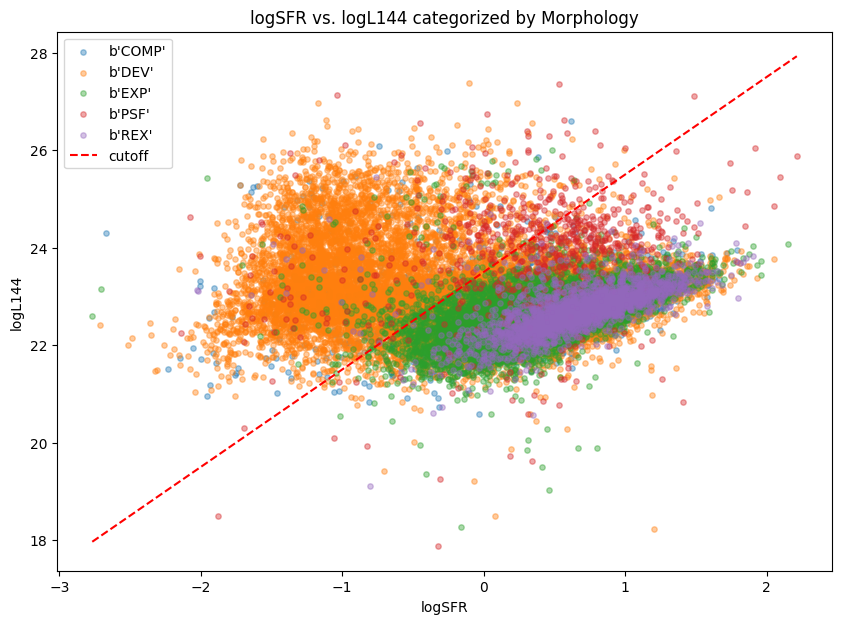

In [7]:
def SFG_AGN_cutoff_plot_preliminary_line(p1, p2, clean_table):
    """
    Plots two parameters with color-coding based on morphological type, with a cutoff line between linear scaling and AGN driven. 
    """
    fig, ax = plt.subplots(figsize=(10, 7))

    # 1. Handle NaN values to ensure polyfit and plotting work correctly
    mask = ~np.isnan(clean_table[p1]) & ~np.isnan(clean_table[p2])
    data = clean_table[mask]

    # 2. np.unique returns the sorted unique elements of an array ---> PSF, REX, DEV, EXP, COMP
    morph_types = np.unique(data['Type'])
    for m_type in morph_types:
        type_mask = (data['Type'] == m_type) # filter through each type
        # if we run: mask = (data['Type'] == "DEV"), we get the butterfly figure as before. 
        ax.scatter(
            data[p1][type_mask],  # apply 'type' mask
            data[p2][type_mask], 
            label=m_type, 
            alpha=0.4,   # Transparency for overlapping points
            s=15         # Adjusted point size for clarity
        )


    '''CUTOFF LINE: done visually this time'''
    intercept = 23.5
    slope = 2

    x_fit = np.linspace(np.min(data[p1]), np.max(data[p1]), num=50)
    y_fit = x_fit * slope + intercept

    ax.plot(x_fit, y_fit, '--', color = 'r', label = "cutoff")
    
    ax.set_xlabel(p1)
    ax.set_ylabel(p2)
    ax.set_title(f"{p1} vs. {p2} categorized by Morphology")
    # ax.legend(title="Morphology Type")
    #plt.grid(True, linestyle=':', alpha=0.6)
    ax.legend()
    plt.savefig("first_draft_plots/mariposa_plot_asdf")
    plt.show()

SFG_AGN_cutoff_plot_preliminary_line("logSFR", "logL144",  clean_data) # cannot do this before clean data, because we wouldn't have L144 otherwise. 

In [8]:
# Cutoff: 
''' Function compute_slope not really necessary for our case right now. 
def compute_slope_intercept(x1, x2, y1, y2):
    x1 = 0.880
    x2 = -0.324
    y1 = 27.65
    y2 = 26.27

    slope = (y2-y1) / (x2-x1)
    intercept = y1 - slope * x1

    return slope, intercept'''


def bool_cutoff_SFG(slope, intercept, data):
    '''
    Definition: Function that will cut off elements under the line that defines the SFG vs. AGN cutoff. 
    To do so, we need to filter out all elements with logL144 > y(logSFR)
    '''
    
    is_agn = data['logL144'] > (slope * data['logSFR'] + intercept)
    data['cutoff'] = is_agn
    # Here, True represents that the value is above the cutoff+ --> AGN in origin

    # Write also a column which is logL144 above cutoff line. 
    data['logL144_above'] = np.nan
    #data['logL144_above'].unit = logL144 units
    data['logL144_above'][is_agn] = data['logL144'][is_agn] - (slope * data['logSFR'][is_agn] + intercept)
    
    data.write('cutoff_table.fits', format='fits', overwrite=True)

    return data

def excess_radio_filter(data):
    excess_mask = np.where(data['cutoff']==True)
    return data[excess_mask]

def print_CR(data):
    '''
    Defn: Function to compute the contamination rate of a galaxy. 
    Population = "all elements that have type category" = len(data['Type']) 
    SFG = "star forming galaxies" = Morphology Type = REX or EXP
    '''
    Population = len(data)
    SFG = np.sum(data['Type'] == "REX") + np.sum(data['Type'] == "EXP") # Sum to get 'True' values in mask

    print(f"Contamination Rate = {SFG / float(Population) * 100 :.2f}%")

Contamination Rate = 3.59%


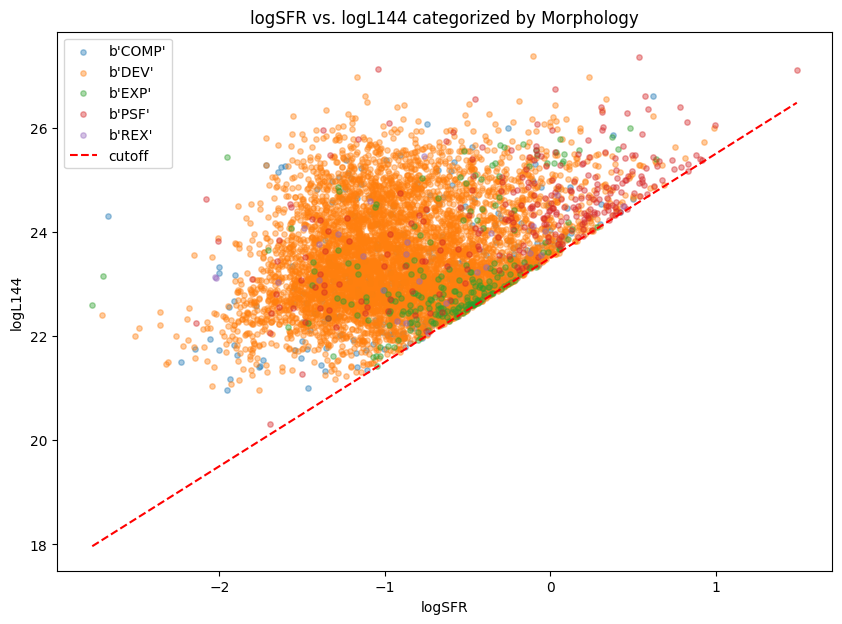

In [9]:
intercept = 23.5
slope = 2

#clean_data = load_fits_table("clean_table.fits")

cut_data = bool_cutoff_SFG(slope, intercept, clean_data)
# Print also CR of data
print_CR(excess_radio_filter(cut_data))

#Check correctness of cut visually: 
SFG_AGN_cutoff_plot_preliminary_line("logSFR", "logL144",  excess_radio_filter(cut_data))

In [10]:
cut_data

PlateSDSS,FiberSDSS,MJDSDSS,Ftot,zphot,logMass,Type,r50,CompSize,logSFR,logL144,rho,radius50,kpcSize,cutoff,logL144_above
,,d,mJy,,log(solMass),,arcsec,arcsec,log(solMass.yr**-1),,solMass / cm3,cm3,kpc3,,
int32,int16,int32,float64,float64,float64,bytes4,float64,float64,float32,float64,float64,float64,float64,bool,float64
349,2,51699,1.2646232366737619746,0.0701356,10.2175130844116211,EXP,3.197971,--,0.253,22.1573877578187747872,1.5535131847850484e-57,1.3636508175835773e+22,--,False,nan
349,25,51699,1.0102712235588247047,0.166734,10.8064422607421875,DEV,6.150081,--,0.663,22.8026171371526125142,8.78184920700956e-59,5.58370619801798e+22,--,False,nan
349,85,51699,2.4999648721656786421,0.109067,10.6218328475952148,DEV,4.457041,--,0.888,22.8333053007957822444,4.4334503990372595e-58,2.8248851445109586e+22,--,False,nan
349,181,51699,5.0609848096918064186,0.0395527,--,DEV,14.08715,--,0.311,22.2646992736611792907,--,3.512787009909514e+22,--,False,nan
349,191,51699,3.7008151341755879393,0.0957429,10.3283538818359375,EXP,4.277628,--,0.396,22.8917519908556812425,3.602130926649705e-58,2.416769656094035e+22,--,False,nan
349,200,51699,1.5355438107514209900,0.15159,10.7066545486450195,EXP,2.555861,--,0.895,22.9033310980754762909,1.2300380756034276e-57,2.1456018158815107e+22,--,False,nan
349,223,51699,2.3007047757587058001,0.166867,11.1003141403198242,DEV,2.494456,--,1.228,23.1607168530237395032,2.584210583735379e-57,2.2662050869126963e+22,--,False,nan
349,224,51699,1.3245362073503319511,0.112806,--,EXP,3.329904,--,0.504,22.5863533560256328769,--,2.1735215990111388e+22,--,False,nan


Here, discuss how the cutoff is applied, and discuss how the low CR value obtained is indicative of the goodness of the criteria being used to distinguish between AGN and SFG populations. 

# Examining Density: 

## rho vs. logL144

<>:24: SyntaxWarning: invalid escape sequence '\o'
<>:24: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_10064/2137840892.py:24: SyntaxWarning: invalid escape sequence '\o'
  '''Below is specific for only p1 = 'rho' , p2 = 'logL144'


Successfully loaded 40476 sources from disk.


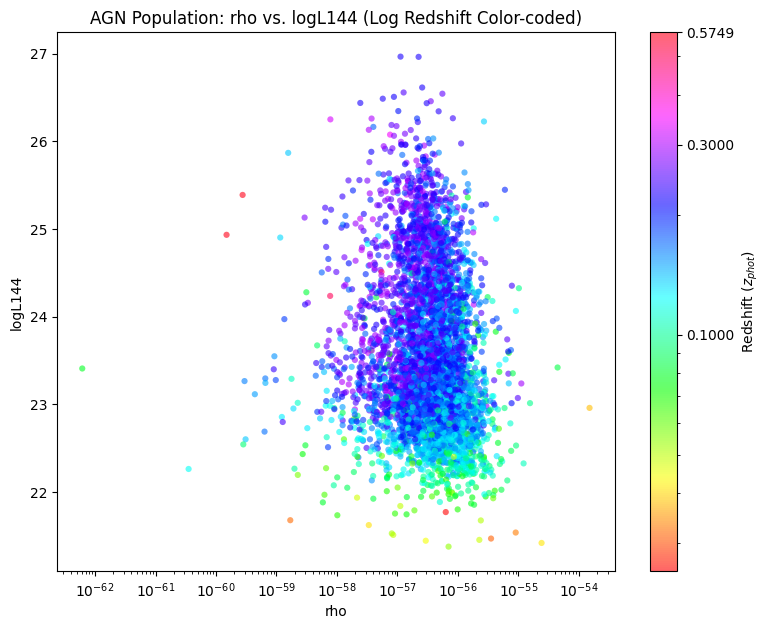

In [11]:
def zscale_rho_logL144(data_table, p1, p2):
    dev_data = data_table # [dev_mask] NO NEED TO FILTER ONLY BY DEV!!!!
    
    # 2. Filter out NaNs for rho and logL144 to ensure clean plotting
    nan_mask = ~np.isnan(dev_data[p1]) & ~np.isnan(dev_data[p2]) 
    plot_data = dev_data[nan_mask]
    
    fig, ax = plt.subplots(figsize=(9, 7))
    ax.set_xscale('log')
    
    sc = ax.scatter(
        plot_data[p1], 
        plot_data[p2], 
        c=plot_data['zphot'], # color grading based on redshift
        norm=mcolors.LogNorm(),
        cmap= 'hsv', #'viridis',       
        alpha=0.6, 
        s=20,
        edgecolors='none'
    )

    
    # 5. Add labels and title
    '''Below is specific for only p1 = 'rho' , p2 = 'logL144'
    ax.set_xlabel(r'$\rho$ ($M_{\odot}$ / cm$^3$)')
    ax.set_ylabel('logL144 (dex W/Hz)')
    '''
    
    ax.set_xlabel(p1)
    ax.set_ylabel(p2)
    
    ax.set_title(f'AGN Population: {p1} vs. {p2} (Log Redshift Color-coded)')

    ####### Below is ticker settings, which can be removed
    # They have been included to get a mind idea
    z_max = plot_data['zphot'].max()
    custom_ticks = [0.1, 0.3, z_max]
    cbar = plt.colorbar(sc, ticks=custom_ticks) 
    # Use ScalarFormatter so 0.1 doesn't stay hidden or turn into 10^-1
    cbar.ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    
    # Optional: ensure minor ticks don't clutter the custom log scale
    cbar.ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    ###################

    cbar.set_label('Redshift ($z_{phot}$)')
    plt.savefig("first_draft_plots/simple_RhoLogl144")
    plt.show()

cut_data = load_fits_table("cutoff_table.fits")
excess_cut_data = excess_radio_filter(cut_data)
zscale_rho_logL144(excess_cut_data, 'rho', 'logL144')

In [12]:
excess_cut_data

PlateSDSS,FiberSDSS,MJDSDSS,Ftot,zphot,logMass,Type,r50,CompSize,logSFR,logL144,rho,radius50,kpcSize,cutoff,logL144_above
,,d,mJy,,log(solMass),,arcsec,arcsec,log(solMass.yr**-1),,solMass / cm3,cm3,kpc3,,
int32,int16,int32,float64,float64,float64,bytes4,float64,float64,float32,float64,float64,float64,float64,bool,float64
349,377,51699,38.2339549104478990671,0.334585,--,PSF,0,--,--,24.9653222589046670521,--,--,--,True,24.965322258904667
349,392,51699,7.2001103476032346506,0.116718,--,DEV,6.86262,--,-1.423,23.3508621539992660132,--,4.6140915026092414e+22,--,True,2.6968621101302475
349,466,51699,0.6816195674295146834,0.161452,11.1950006484985352,DEV,2.513683,--,-1.288,22.6043217086985421815,3.405302462458502e-57,2.2228941466135935e+22,--,True,1.68032168390301
349,485,51699,3.2313357736812378107,0.0249104,--,COMP,9.687386,--,--,21.6694031139567151456,--,1.5484538766163391e+22,--,True,21.669403113956715
349,492,51699,0.9625532452765509506,0.563034,4.6236805915832520,PSF,0,--,--,23.7853626733469845078,--,--,--,True,23.785362673346985
349,503,51699,0.9017159862475083720,0.0770104,--,DEV,2.119771,--,-0.908,22.0911131729529373047,--,9.845271285682892e+21,--,True,0.40711315769414824
349,604,51699,10.0904356142889071180,0.243655,--,DEV,1.853132,--,-1.078,24.1228380449933119678,--,2.261702092916551e+22,--,True,2.7788379439038344
350,309,51691,1.7045572101917541019,0.172235,11.3893280029296875,DEV,2.958245,--,-1.670,23.0573899201755629917,2.790358097658199e-57,2.757569608514667e+22,--,True,2.8973898343448745


Above we obtain a plot for only the AGN above cutoff population. That means, we are observing logL144 vs. rho for the AGN population. We observe that for small changes in rho, we get huge pillars, spanning orders of magnitude in logL144. It is unclear whether this effect is attributable only to rho, or whether there might be some hidden variables at play which we are not measuring. 

Also, it should be worrying that we observe higher logL144 for galaxies with higher z, which implies younger galaxies. Yet, we can counter at the same time that age of the universe might not be all that representative of age the AGN galaxy. Instead, size might be a more accurate measure. Below, we include that plot. It is important to note that here we are plotting the size of the radio emission, which is a measure of how much emission has been launched, and hence of age, in general. Yet, we can expect some outliars for multiple emission regions which don't have to do exclusively with AGN. 

## Size & Age

---
For size, we choose **Composite_Size**: The maximum angular size (in arcseconds) of a virtual boundary (a "convex hull") wrapped around all separate radio components (e.g., the core, the northern lobe, and the southern lobe) that have been physically associated with a single host galaxy.

Let's see what this gives us: 

<>:24: SyntaxWarning: invalid escape sequence '\o'
<>:24: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_10064/3030892940.py:24: SyntaxWarning: invalid escape sequence '\o'
  '''Below is specific for only p1 = 'rho' , p2 = 'logL144'


Successfully loaded 40476 sources from disk.


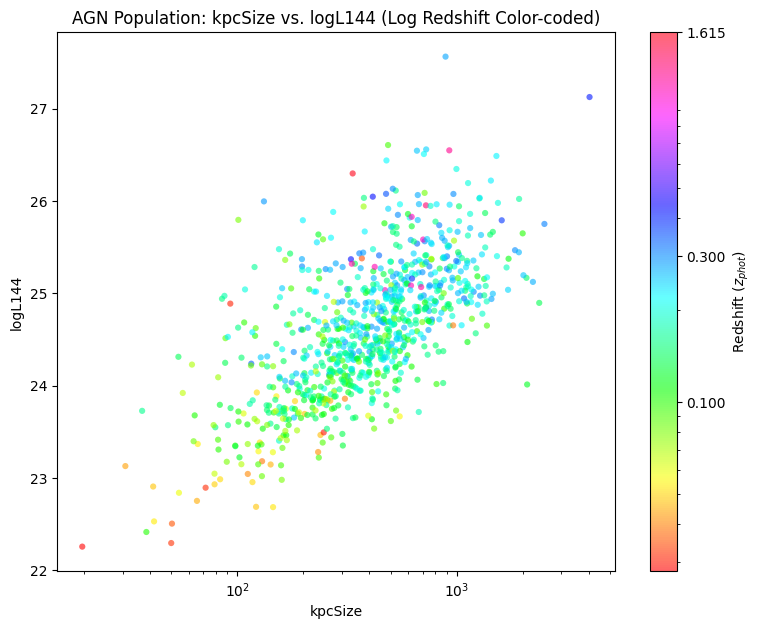

In [13]:
def zscale_rho_logL144(data_table, p1, p2):
    dev_data = data_table # [dev_mask] NO NEED TO FILTER ONLY BY DEV!!!!
    
    # 2. Filter out NaNs for rho and logL144 to ensure clean plotting
    nan_mask = ~np.isnan(dev_data[p1]) & ~np.isnan(dev_data[p2])
    plot_data = dev_data[nan_mask]
    
    fig, ax = plt.subplots(figsize=(9, 7))
    ax.set_xscale('log')
    
    sc = ax.scatter(
        plot_data[p1], 
        plot_data[p2], 
        c=plot_data['zphot'], # color grading based on redshift
        norm=mcolors.LogNorm(),
        cmap= 'hsv', #'viridis',       
        alpha=0.6, 
        s=20,
        edgecolors='none'
    )

    
    # 5. Add labels and title
    '''Below is specific for only p1 = 'rho' , p2 = 'logL144'
    ax.set_xlabel(r'$\rho$ ($M_{\odot}$ / cm$^3$)')
    ax.set_ylabel('logL144 (dex W/Hz)')
    '''
    
    ax.set_xlabel(p1)
    ax.set_ylabel(p2)
    
    ax.set_title(f'AGN Population: {p1} vs. {p2} (Log Redshift Color-coded)')

    ####### Below is ticker settings, which can be removed
    # They have been included to get a mind idea
    z_max = plot_data['zphot'].max()
    custom_ticks = [0.1, 0.3, z_max]
    cbar = plt.colorbar(sc, ticks=custom_ticks) 
    # Use ScalarFormatter so 0.1 doesn't stay hidden or turn into 10^-1
    cbar.ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    
    # Optional: ensure minor ticks don't clutter the custom log scale
    cbar.ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    ###################

    cbar.set_label('Redshift ($z_{phot}$)')
    plt.savefig("first_draft_plots/kpcSize_logL144")
    plt.show()

cut_data = load_fits_table("cutoff_table.fits")
excess_cut_data = excess_radio_filter(cut_data)
zscale_rho_logL144(excess_cut_data, 'kpcSize', 'logL144')

This relation shows that there is some linear scaling between size and luminosity. Hence, we can expect that the "columns" we observe in the logL144 vs. rho plot is attributed to different AGN galaxy ages (albeit each of them can be found in many different redshifts. )

It is, however, suprising to see how the highest size galaxies are those  with highest redshift (younger age of the universe), and the galaxies with least size in our sample are those with lower redshift value (older universe). We can attribute this to the fact that we are only probing the nearby universe, with the maximum redshift being 1.615, which is far from the newest telescopes (e.g. JWST at redshifts of 13). 

## Mass

<>:24: SyntaxWarning: invalid escape sequence '\o'
<>:24: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_10064/1814946201.py:24: SyntaxWarning: invalid escape sequence '\o'
  '''Below is specific for only p1 = 'rho' , p2 = 'logL144'


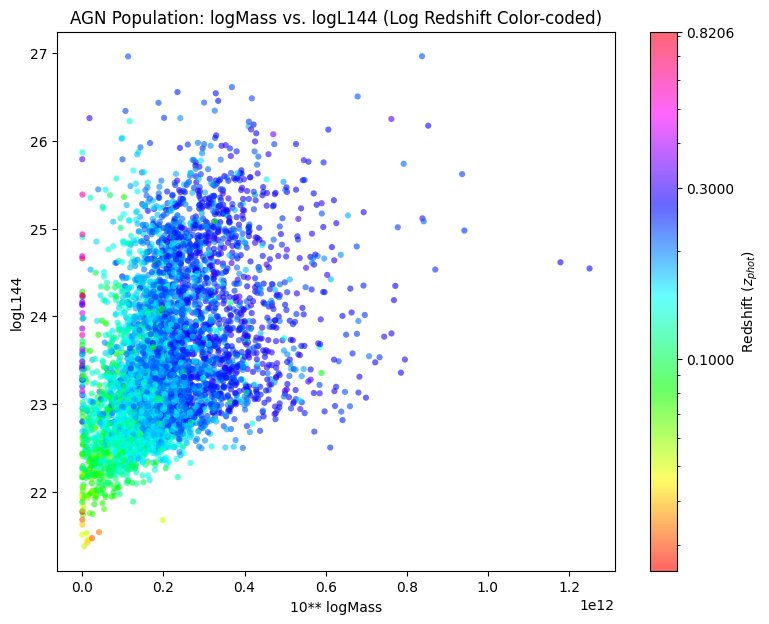

In [14]:
def mass_actual_zscale_plot_DEV(data_table, p1, p2):
    dev_data = data_table
    
    # 2. Filter out NaNs for rho and logL144 to ensure clean plotting
    nan_mask = ~np.isnan(dev_data[p1]) & ~np.isnan(dev_data[p2])
    plot_data = dev_data[nan_mask]
    
    fig, ax = plt.subplots(figsize=(9, 7))
    #ax.set_xscale('log')
    
    sc = ax.scatter(
        10 ** plot_data[p1], # plot actual mass 
        plot_data[p2], 
        c=plot_data['zphot'], # color grading based on redshift
        norm=mcolors.LogNorm(),
        cmap= 'hsv', #'viridis',       
        alpha=0.6, 
        s=20,
        edgecolors='none'
    )

    
    # 5. Add labels and title
    '''Below is specific for only p1 = 'rho' , p2 = 'logL144'
    ax.set_xlabel(Mass '$(10^{M_{\odot})}$')
    ax.set_ylabel('logL144 (dex W/Hz)')
    '''
    
    #ax.set_xlabel(r'Mass ($10^{M_{\odot}}$)')    
    ax.set_xlabel(f"10** {p1}")
    ax.set_ylabel(p2)

    ax.set_title(f'AGN Population: {p1} vs. {p2} (Log Redshift Color-coded)')

    ####### Below is ticker settings, which can be removed
    # They have been included to get a mind idea
    z_max = plot_data['zphot'].max()
    custom_ticks = [0.1, 0.3, z_max]
    cbar = plt.colorbar(sc, ticks=custom_ticks) 
    # Use ScalarFormatter so 0.1 doesn't stay hidden or turn into 10^-1
    cbar.ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    
    # Optional: ensure minor ticks don't clutter the custom log scale
    cbar.ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    ###################

    cbar.set_label('Redshift ($z_{phot}$)')
    plt.savefig("first_draft_plots/mass_logL144")
    plt.show()

mass_actual_zscale_plot_DEV(excess_cut_data,'logMass', 'logL144')

### Mass - Density Color-Coded (review)

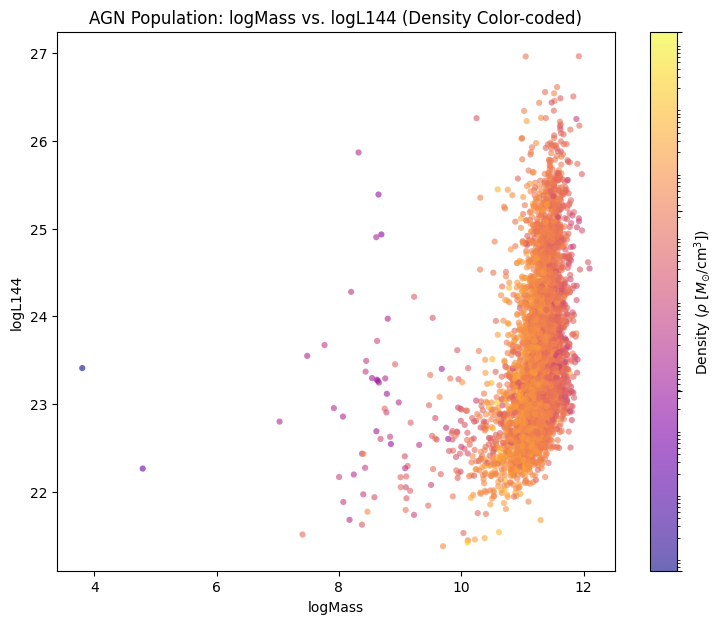

In [17]:
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
import numpy as np

def mass_actual_zscale_plot_DEV(data_table, p1, p2):
    dev_data = data_table
    
    # 2. Filter out NaNs for rho, p1, and p2 to ensure clean plotting
    nan_mask = ~np.isnan(dev_data[p1]) & ~np.isnan(dev_data[p2]) & ~np.isnan(dev_data['rho'])
    plot_data = dev_data[nan_mask]
    
    fig, ax = plt.subplots(figsize=(9, 7))
    
    # Define a LogNorm dynamically based on the min and max density values present
    rho_min = plot_data['rho'].min()
    rho_max = plot_data['rho'].max()
    norm_rho = mcolors.LogNorm(vmin=rho_min, vmax=rho_max)
    
    sc = ax.scatter(
        plot_data[p1],        # plot actual mass 
        plot_data[p2], 
        c=plot_data['rho'],         # Color grading based on density (rho)
        norm=norm_rho,
        cmap='plasma',             # 'viridis' or 'plasma' provide excellent contrast for density
        alpha=0.6, 
        s=20,
        edgecolors='none'
    )
    
    # 5. Add labels and title
    ax.set_xlabel(f"{p1}")
    ax.set_ylabel(p2)
    ax.set_title(f'AGN Population: {p1} vs. {p2} (Density Color-coded)')

    # --- Ticker settings for density (rho) ---
    # Create 4 cleanly spaced logarithmic tick marks from the min exponent to the max exponent
    log_min = np.log10(rho_min)
    log_max = np.log10(rho_max)
    custom_ticks = np.logspace(log_min, log_max, num=4)
    
    cbar = plt.colorbar(sc, ticks=custom_ticks) 
    
    # Use LogFormatterMathtext so tiny floats look like 10^{-65} instead of 0.000...
    cbar.ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext())
    
    # Ensure minor ticks don't overlap or clutter the clean log scale
    cbar.ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    # ----------------------------------------

    cbar.set_label('Density ($\\rho$ [$M_{\\odot}/\\text{cm}^3$])')
    
    # Save with a descriptive filename reflecting the density coding change
    plt.savefig("first_draft_plots/mass_logL144_density_coded")
    plt.show()

# Execution
mass_actual_zscale_plot_DEV(excess_cut_data, 'logMass', 'logL144')

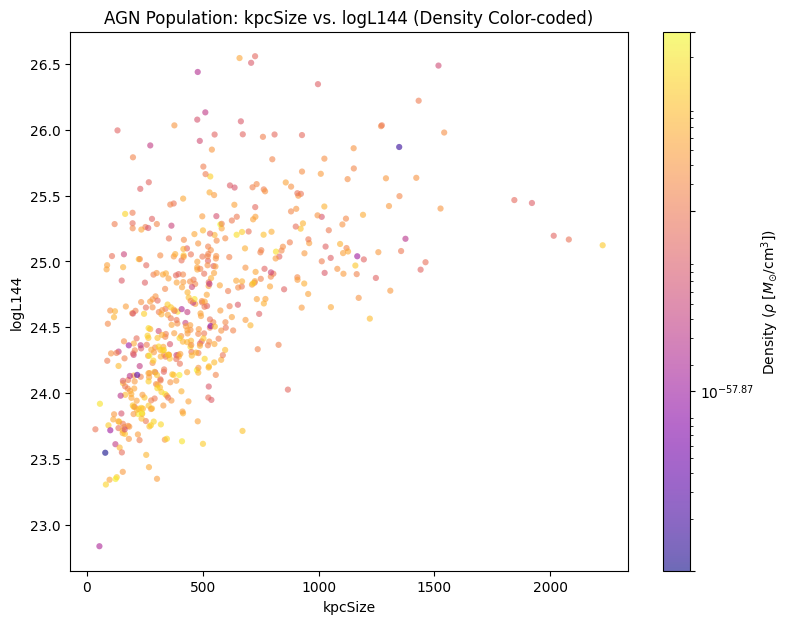

In [23]:
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
import numpy as np

def mass_actual_zscale_plot_DEV(data_table, p1, p2):
    dev_data = data_table
    
    # 2. Filter out NaNs for rho, p1, and p2 to ensure clean plotting
    nan_mask = ~np.isnan(dev_data[p1]) & ~np.isnan(dev_data[p2]) & ~np.isnan(dev_data['rho'])
    plot_data = dev_data[nan_mask]
    
    fig, ax = plt.subplots(figsize=(9, 7))
    
    # Define a LogNorm dynamically based on the min and max density values present
    rho_min = plot_data['rho'].min()
    rho_max = plot_data['rho'].max()
    norm_rho = mcolors.LogNorm(vmin=rho_min, vmax=rho_max)
    
    sc = ax.scatter(
        plot_data[p1],        # plot actual mass 
        plot_data[p2], 
        c=plot_data['rho'],         # Color grading based on density (rho)
        norm=norm_rho,
        cmap='plasma',             # 'viridis' or 'plasma' provide excellent contrast for density
        alpha=0.6, 
        s=20,
        edgecolors='none'
    )
    
    # 5. Add labels and title
    ax.set_xlabel(f"{p1}")
    ax.set_ylabel(p2)
    ax.set_title(f'AGN Population: {p1} vs. {p2} (Density Color-coded)')

    # --- Ticker settings for density (rho) ---
    # Create 4 cleanly spaced logarithmic tick marks from the min exponent to the max exponent
    log_min = np.log10(rho_min)
    log_max = np.log10(rho_max)
    custom_ticks = np.logspace(log_min, log_max, num=4)
    
    cbar = plt.colorbar(sc, ticks=custom_ticks) 
    
    # Use LogFormatterMathtext so tiny floats look like 10^{-65} instead of 0.000...
    cbar.ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext())
    
    # Ensure minor ticks don't overlap or clutter the clean log scale
    cbar.ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    # ----------------------------------------

    cbar.set_label('Density ($\\rho$ [$M_{\\odot}/\\text{cm}^3$])')
    
    # Save with a descriptive filename reflecting the density coding change
    plt.savefig("first_draft_plots/mass_logL144_density_coded")
    plt.show()

# Execution
mass_actual_zscale_plot_DEV(excess_cut_data, 'kpcSize', 'logL144')

## Preliminary Discussion:

So far, we have our plots have shown huge columns that increase in size for decreasing density, as well as increase in logL144 with size of the source (which we attribute to age). We also show that luminosity increases with mass. 

This implies that: 
- More mass implies more material, which launches more energetic jets
- lower densities correspond to higher columns. We attribute this to the AGN feedback making surrounding gas expand. Then, the density decreases, and it drives those cycles of activity that would be consisten with the pillar shape.
- Age also plays a role, since we expect that gravitational pull of galaxy will attract more matter, which fuels the AGN further to drive more energetic outbursts.

Hence, so far our picture of jets can be unified. 

# Advanced Plots

In [81]:
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

def plot_2d_hist_agn_sfg_by_mass_slices(cut_data, num_slices=4, nbins=40, save_dir=None):
    """
    Slices the dataset into mass bins of equal distribution. For each mass slice,
    plots side-by-side 2D histograms (log10(rho) vs logL144) for AGN and SFG sources.
    Saves the resulting figures to disk if save_dir is provided.
    
    Parameters:
    -----------
    cut_data : astropy.table.Table
        The dataset containing 'logMass', 'rho', 'logL144', and 'cutoff'.
    num_slices : int, optional
        The number of equal-distribution mass intervals to create (default is 4).
    nbins : int, optional
        The number of bins along each axis for the 2D histograms (default is 40).
    save_dir : str, optional
        The directory path where the plots should be saved (e.g., './plots').
        If None, figures are only displayed and not saved.
    """
    # Create the directory if it doesn't exist
    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

    # 1. Extract and clean data
    log_mass = np.array(cut_data['logMass'])
    rho = np.array(cut_data['rho'])
    log_l144 = np.array(cut_data['logL144'])
    cutoff = np.array(cut_data['cutoff'])
    
    # Filter out NaNs, Infs, and non-positive densities
    valid_mask = (np.isfinite(log_mass) & np.isfinite(rho) & 
                  np.isfinite(log_l144) & (rho > 0) & ~np.isnan(cutoff))
    
    log_mass = log_mass[valid_mask]
    log_rho = np.log10(rho[valid_mask])
    log_l144 = log_l144[valid_mask]
    cutoff = cutoff[valid_mask]
    
    # 2. Determine global limits so all mass-slice comparisons share the same axes scale
    rho_min, rho_max = np.min(log_rho), np.max(log_rho)
    l144_min, l144_max = np.min(log_l144), np.max(log_l144)
    global_range = [[rho_min, rho_max], [l144_min, l144_max]]
    
    # 3. Compute mass boundaries for equal distributions (quantiles)
    percentiles = np.linspace(0, 100, num_slices + 1)
    mass_edges = np.percentile(log_mass, percentiles)
    
    # 4. Loop through each mass slice and generate a separate side-by-side figure
    for i in range(num_slices):
        low_m = mass_edges[i]
        high_m = mass_edges[i+1]
        
        # Slicing mask for the current mass quantile
        if i == num_slices - 1:
            mass_mask = (log_mass >= low_m) & (log_mass <= high_m)
        else:
            mass_mask = (log_mass >= low_m) & (log_mass < high_m)
            
        slice_rho = log_rho[mass_mask]
        slice_l144 = log_l144[mass_mask]
        slice_cutoff = cutoff[mass_mask]
        
        # Filter into AGN (True) and SFG (False) subgroups within this slice
        agn_mask = (slice_cutoff == True)
        sfg_mask = (slice_cutoff == False)
        
        agn_x, agn_y = slice_rho[agn_mask], slice_l144[agn_mask]
        sfg_x, sfg_y = slice_rho[sfg_mask], slice_l144[sfg_mask]
        
        # Initialize side-by-side figure panels
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5), sharex=True, sharey=True)
        
        # --- LEFT PANEL: AGN 2D Histogram ---
        if len(agn_x) > 0:
            counts1, xedges1, yedges1, im1 = ax1.hist2d(
                agn_x, agn_y, bins=nbins, range=global_range,
                cmap='plasma', norm=mcolors.LogNorm()
            )
            fig.colorbar(im1, ax=ax1, label='AGN Source Counts')
        else:
            ax1.text(0.5, 0.5, 'No AGN data in this slice', ha='center', va='center')
            
        ax1.set_title(f"AGN Sources Sample Size: N = {len(agn_x)}", fontsize=11)
        ax1.set_xlabel(r"$\log_{10}(\rho)$ ($M_{\odot}$ / cm$^3$)")
        ax1.set_ylabel(r"$\log_{10}(L_{144}\,\, [\mathrm{W\, Hz^{-1}}])$")
        ax1.grid(True, linestyle=':', alpha=0.5)
        
        # --- RIGHT PANEL: SFG 2D Histogram ---
        if len(sfg_x) > 0:
            counts2, xedges2, yedges2, im2 = ax2.hist2d(
                sfg_x, sfg_y, bins=nbins, range=global_range,
                cmap='viridis', norm=mcolors.LogNorm()
            )
            fig.colorbar(im2, ax=ax2, label='SFG Source Counts')
        else:
            ax2.text(0.5, 0.5, 'No SFG data in this slice', ha='center', va='center')
            
        ax2.set_title(f"SFG Sources Sample Size: N = {len(sfg_x)}", fontsize=11)
        ax2.set_xlabel(r"$\log_{10}(\rho)$ ($M_{\odot}$ / cm$^3$)")
        ax2.grid(True, linestyle=':', alpha=0.5)
        
        # --- Global Title for the current Mass Interval ---
        pct_low, pct_high = int(percentiles[i]), int(percentiles[i+1])
        '''fig.suptitle(
            f"Mass Slice {i+1} of {num_slices} ({pct_low}th to {pct_high}th percentile)\n"
            f"Mass Interval: $\log_{{10}}(M_*)$ $\in$ [{low_m:.2f}, {high_m:.2f}] — Total N = {len(slice_rho)}",
            fontsize=13, fontweight='bold', y=1.05
        )'''
        
        plt.tigignitinght_layout()
        
        # --- SAVE THE FIGURE (Must happen BEFORE plt.show()) ---
        if save_dir is not None:
            # Replaces decimal points in filenames to avoid extensions confusion
            low_m_str = f"{low_m:.2f}".replace('.', 'p')
            high_m_str = f"{high_m:.2f}".replace('.', 'p')
            filename = f"mass_slice_{i+1}_logM_{low_m_str}_to_{high_m_str}.png"
            filepath = os.path.join(save_dir, filename)
            
            # dpi=300 keeps text crisp; bbox_inches='tight' accounts for y=1.05 shift
            plt.savefig(filepath, dpi=300, bbox_inches='tight')
            print(f"Saved: {filepath}")
        
        plt.show()

<>:108: SyntaxWarning: invalid escape sequence '\l'
<>:108: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_46004/313383725.py:108: SyntaxWarning: invalid escape sequence '\l'
  '''fig.suptitle(


Saved: advanced_plots/mass_slice_1_logM_3p80_to_10p43.png


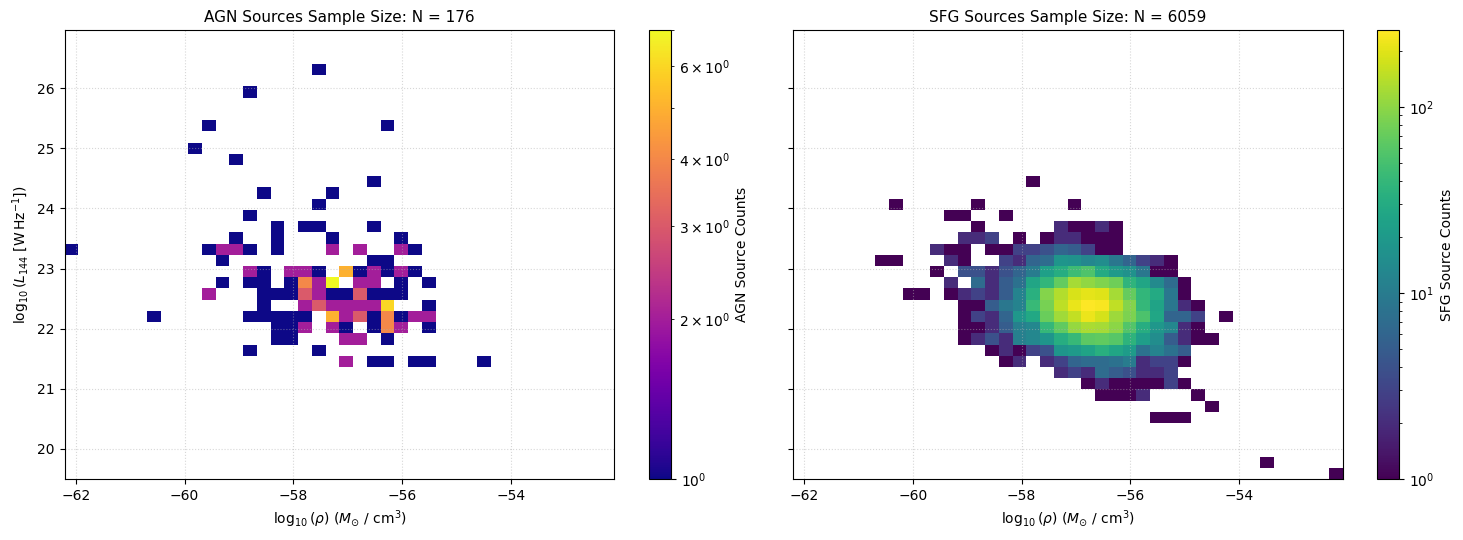

Saved: advanced_plots/mass_slice_2_logM_10p43_to_10p79.png


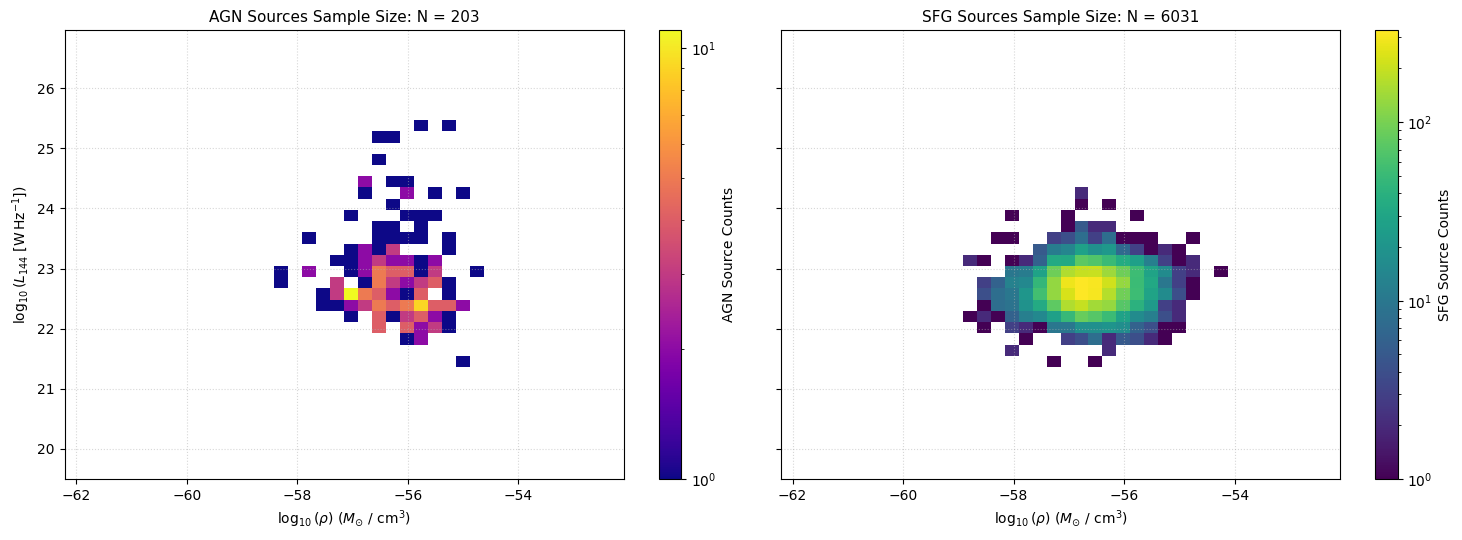

Saved: advanced_plots/mass_slice_3_logM_10p79_to_11p11.png


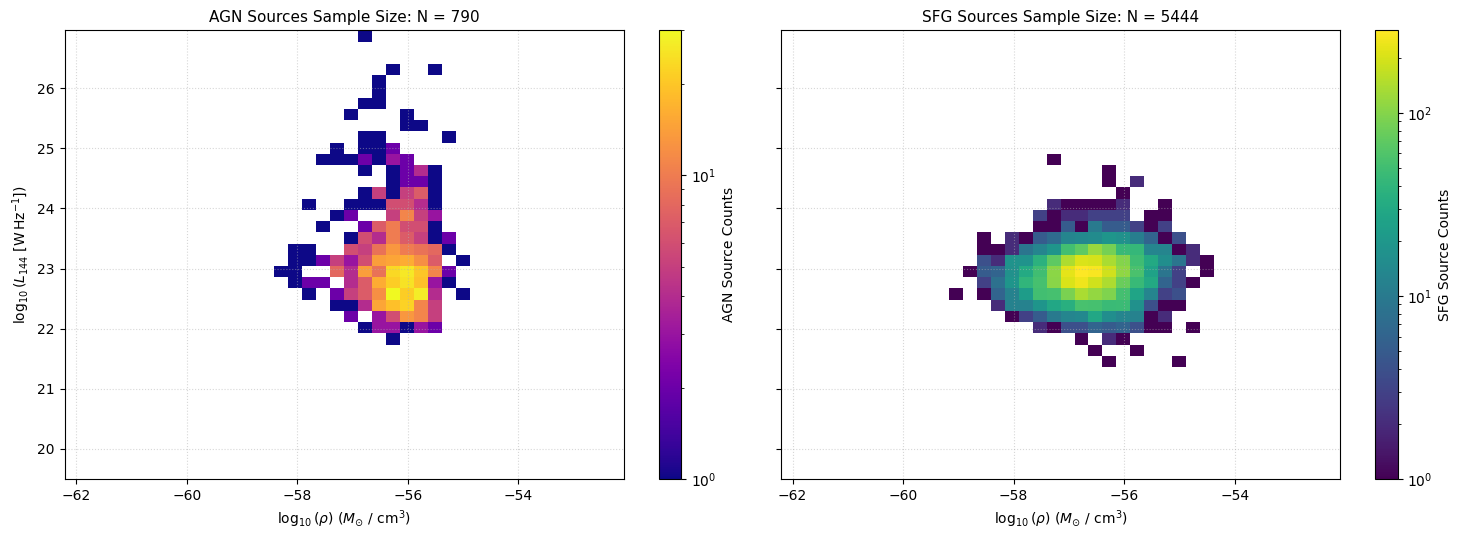

Saved: advanced_plots/mass_slice_4_logM_11p11_to_12p10.png


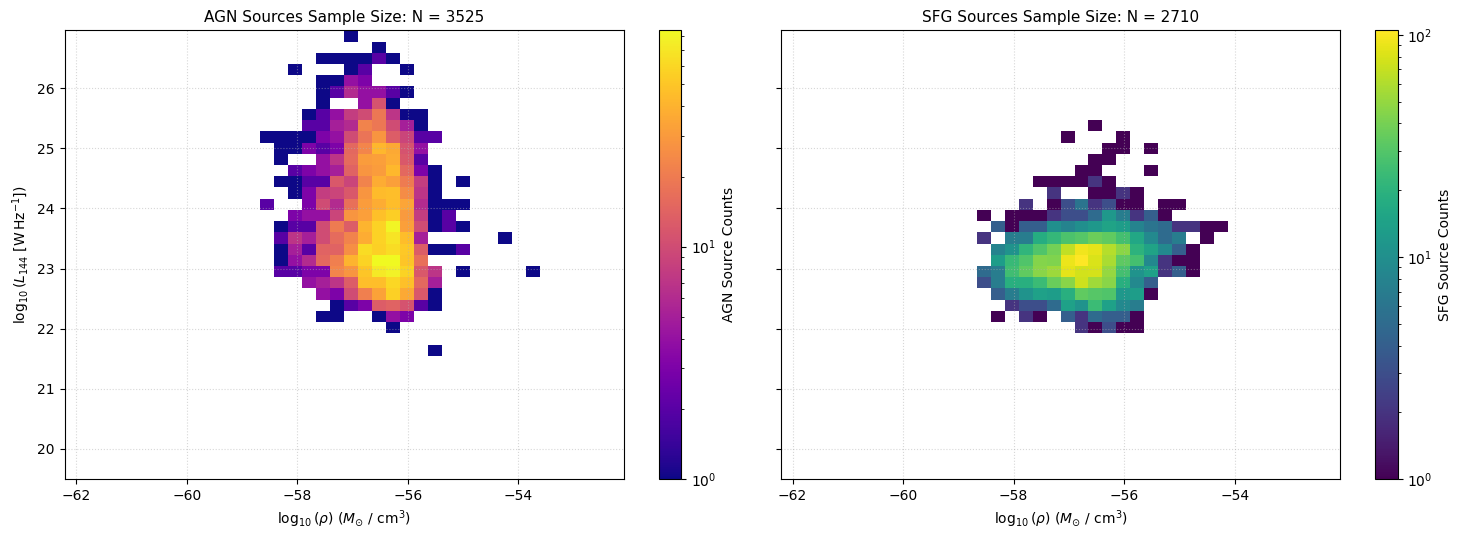

In [82]:
plot_2d_hist_agn_sfg_by_mass_slices(cut_data, num_slices=4, save_dir='advanced_plots')
#plot_2d_hist_agn_sfg_by_mass_slices(cut_data, num_slices=4, nbins=35)

In [83]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker

def plot_scatter_marginal_hist_by_source_type(data_table, num_slices=4, nbins=40, save_dir=None):
    """
    Plots a multi-panel grid for discrete mass intervals. For each mass slice,
    generates two side-by-side joint scatter plots (color-coded by redshift with 
    marginal histograms on the sides) separated into AGN and SFG populations.
    Saves the resulting figures to disk if save_dir is provided.
    
    Parameters:
    -----------
    data_table : astropy.table.Table or pandas.DataFrame
        The dataset containing 'rho', 'logL144', 'zphot', 'logMass', and 'cutoff'.
    num_slices : int, optional
        Number of equal-distribution mass intervals (quantiles) to iterate through.
    nbins : int, optional
        Number of bins for the marginal histograms.
    save_dir : str, optional
        The directory path where the plots should be saved (e.g., './scatter_plots').
        If None, figures are only displayed and not saved.
    """
    # Create the directory if it doesn't exist
    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

    # 1. Strip and filter out invalid rows
    valid_mask = (np.isfinite(data_table['rho']) & (data_table['rho'] > 0) &
                  np.isfinite(data_table['logL144']) & 
                  np.isfinite(data_table['zphot']) & 
                  np.isfinite(data_table['logMass']) &
                  ~np.isnan(data_table['cutoff']))
    
    clean_data = data_table[valid_mask]
    
    rho_vals = np.array(clean_data['rho'])
    log_rho_vals = np.log10(rho_vals)
    l144_vals = np.array(clean_data['logL144'])
    z_vals = np.array(clean_data['zphot'])
    mass_vals = np.array(clean_data['logMass'])
    cutoff_vals = np.array(clean_data['cutoff'])
    
    # 2. Lock structural limits globally to allow seamless comparison across slices
    rho_min, rho_max = rho_vals.min(), rho_vals.max()
    log_rho_min, log_rho_max = log_rho_vals.min(), log_rho_vals.max()
    l144_min, l144_max = l144_vals.min(), l144_vals.max()
    z_min, z_max = z_vals.min(), z_vals.max()
    
    # Pre-calculate unified histogram bin arrays
    bins_x = np.logspace(log_rho_min, log_rho_max, nbins)
    bins_y = np.linspace(l144_min, l144_max, nbins)
    
    # Standardized colorbar scaling for redshift mapping
    z_norm = mcolors.LogNorm(vmin=z_min, vmax=z_max)
    
    # 3. Create equal-distribution mass intervals
    percentiles = np.linspace(0, 100, num_slices + 1)
    mass_edges = np.percentile(mass_vals, percentiles)
    
    # 4. Iterate over mass intervals
    for i in range(num_slices):
        low_m = mass_edges[i]
        high_m = mass_edges[i+1]
        
        # Apply current mass slice slice
        if i == num_slices - 1:
            mass_mask = (mass_vals >= low_m) & (mass_vals <= high_m)
        else:
            mass_mask = (mass_vals >= low_m) & (mass_vals < high_m)
            
        m_rho = rho_vals[mass_mask]
        m_l144 = l144_vals[mass_mask]
        m_z = z_vals[mass_mask]
        m_cutoff = cutoff_vals[mass_mask]
        
        # Separate into AGN (True) and SFG (False) groups
        agn_mask = (m_cutoff == True)
        sfg_mask = (m_cutoff == False)
        
        # 5. Initialize layout with GridSpec
        fig = plt.figure(figsize=(18, 8))
        
        # Columns layout setup: 
        # Col 0: AGN Scatter | Col 1: AGN Hist Y | Col 2: Buffer Gap | Col 3: SFG Scatter | Col 4: SFG Hist Y
        gs = fig.add_gridspec(2, 5, width_ratios=(4, 1, 0.5, 4, 1), height_ratios=(1, 4),
                              left=0.06, right=0.91, bottom=0.1, top=0.88,
                              wspace=0.05, hspace=0.05)
        
        # Allocate Axis Panels (Sharing Y axes dynamically binds them structurally)
        ax_agn = fig.add_subplot(gs[1, 0])
        ax_agn_hx = fig.add_subplot(gs[0, 0], sharex=ax_agn)
        ax_agn_hy = fig.add_subplot(gs[1, 1], sharey=ax_agn)
        
        ax_sfg = fig.add_subplot(gs[1, 3], sharey=ax_agn)
        ax_sfg_hx = fig.add_subplot(gs[0, 3], sharex=ax_sfg)
        ax_sfg_hy = fig.add_subplot(gs[1, 4], sharey=ax_sfg)
        
        # Strip internal labels to maintain clean margins
        ax_agn_hx.tick_params(axis="x", labelbottom=False)
        ax_agn_hy.tick_params(axis="y", labelleft=False)
        ax_sfg_hx.tick_params(axis="x", labelbottom=False)
        ax_sfg_hy.tick_params(axis="y", labelleft=False)
        ax_sfg.tick_params(axis="y", labelleft=False) # Hides overlapping center tick marks
        
        # Format axes environment properties
        for ax_main in [ax_agn, ax_sfg]:
            ax_main.set_xscale('log')
            ax_main.set_xlim(rho_min, rho_max)
            ax_main.set_ylim(l144_min, l144_max)
            ax_main.set_xlabel(r'$\rho$ ($M_{\odot}$ / cm$^3$)')
            ax_main.grid(True, linestyle=':', alpha=0.5)
            
        ax_agn.set_ylabel(r'$\log_{10}(L_{144}\,\, [\mathrm{W\, Hz^{-1}}])$')
        
        # 6. Scatter and Bin Data for Left Panel: AGN Sources
        x_agn, y_agn, z_agn = m_rho[agn_mask], m_l144[agn_mask], m_z[agn_mask]
        sc_agn = None
        if len(x_agn) > 0:
            sc_agn = ax_agn.scatter(x_agn, y_agn, c=z_agn, norm=z_norm, cmap='hsv', alpha=0.6, s=22, edgecolors='none')
            ax_agn_hx.hist(x_agn, bins=bins_x, color='orangered', alpha=0.7)
            ax_agn_hy.hist(y_agn, bins=bins_y, orientation='horizontal', color='orangered', alpha=0.7)
        else:
            ax_agn.text(0.5, 0.5, 'No AGN Population Data', ha='center', va='center')
        ax_agn_hx.set_title(f"AGN Sources (`cutoff` == True) | N = {len(x_agn)}", fontsize=11, fontweight='semibold')
        ax_agn_hx.grid(True, linestyle=':', alpha=0.3)
        ax_agn_hy.grid(True, linestyle=':', alpha=0.3)
        
        # 7. Scatter and Bin Data for Right Panel: Star Forming Galaxies (SFG)
        x_sfg, y_sfg, z_sfg = m_rho[sfg_mask], m_l144[sfg_mask], m_z[sfg_mask]
        sc_sfg = None
        if len(x_sfg) > 0:
            sc_sfg = ax_sfg.scatter(x_sfg, y_sfg, c=z_sfg, norm=z_norm, cmap='hsv', alpha=0.6, s=22, edgecolors='none')
            ax_sfg_hx.hist(x_sfg, bins=bins_x, color='deepskyblue', alpha=0.7)
            ax_sfg_hy.hist(y_sfg, bins=bins_y, orientation='horizontal', color='deepskyblue', alpha=0.7)
        else:
            ax_sfg.text(0.5, 0.5, 'No SFG Population Data', ha='center', va='center')
        ax_sfg_hx.set_title(f"SFG Sources (`cutoff` == False) | N = {len(x_sfg)}", fontsize=11, fontweight='semibold')
        ax_sfg_hx.grid(True, linestyle=':', alpha=0.3)
        ax_sfg_hy.grid(True, linestyle=':', alpha=0.3)
        
        # 8. Shared Colorbar configuration tracking redshift mapping values
        active_sc = sc_sfg if sc_sfg is not None else sc_agn
        if active_sc is not None:
            cax = fig.add_axes([0.93, 0.1, 0.015, 0.62])
            cbar = fig.colorbar(active_sc, cax=cax)
            cbar.ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
            cbar.ax.yaxis.set_minor_formatter(mticker.NullFormatter())
            cbar.set_label('Redshift ($z_{phot}$)', fontsize=11)
            
        # Global Figure Header Title per mass chunk
        pct_low, pct_high = int(percentiles[i]), int(percentiles[i+1])
        fig.suptitle(
            f"Mass Slice {i+1} of {num_slices} ({pct_low}th to {pct_high}th percentile)\n"
            f"Mass Limits: $\log_{{10}}(M_*)$ $\in$ [{low_m:.2f}, {high_m:.2f}] — Sliced Total N = {len(m_rho)}",
            fontsize=13, fontweight='bold', y=0.97
        )
        
        # --- SAVE THE FIGURE (Must happen BEFORE plt.show()) ---
        if save_dir is not None:
            # Replaces decimal points in filenames to prevent extension issues
            low_m_str = f"{low_m:.2f}".replace('.', 'p')
            high_m_str = f"{high_m:.2f}".replace('.', 'p')
            filename = f"joint_scatter_slice_{i+1}_logM_{low_m_str}_to_{high_m_str}.png"
            filepath = os.path.join(save_dir, filename)
            
            # Using bbox_inches='tight' catches the manual colorbar bounding box and title safely
            plt.savefig(filepath, dpi=300, bbox_inches='tight')
            print(f"Saved: {filepath}")

        plt.show()

<>:157: SyntaxWarning: invalid escape sequence '\l'
<>:157: SyntaxWarning: invalid escape sequence '\i'
<>:157: SyntaxWarning: invalid escape sequence '\l'
<>:157: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_46004/126568215.py:157: SyntaxWarning: invalid escape sequence '\l'
  f"Mass Limits: $\log_{{10}}(M_*)$ $\in$ [{low_m:.2f}, {high_m:.2f}] — Sliced Total N = {len(m_rho)}",
/tmp/ipykernel_46004/126568215.py:157: SyntaxWarning: invalid escape sequence '\i'
  f"Mass Limits: $\log_{{10}}(M_*)$ $\in$ [{low_m:.2f}, {high_m:.2f}] — Sliced Total N = {len(m_rho)}",


Saved: ./joint_scatters/joint_scatter_slice_1_logM_3p80_to_10p43.png


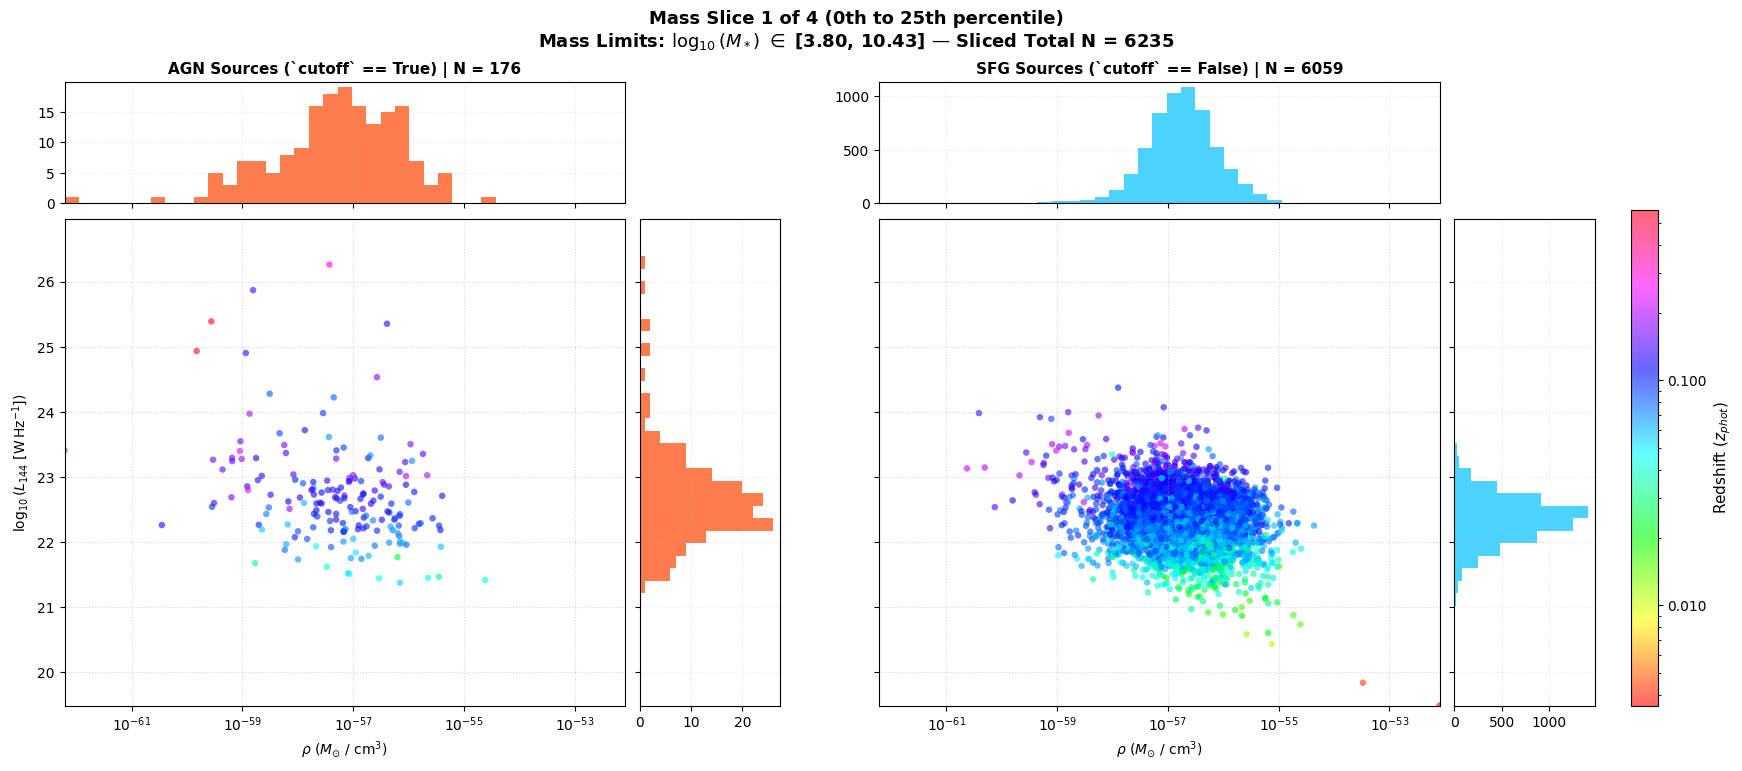

Saved: ./joint_scatters/joint_scatter_slice_2_logM_10p43_to_10p79.png


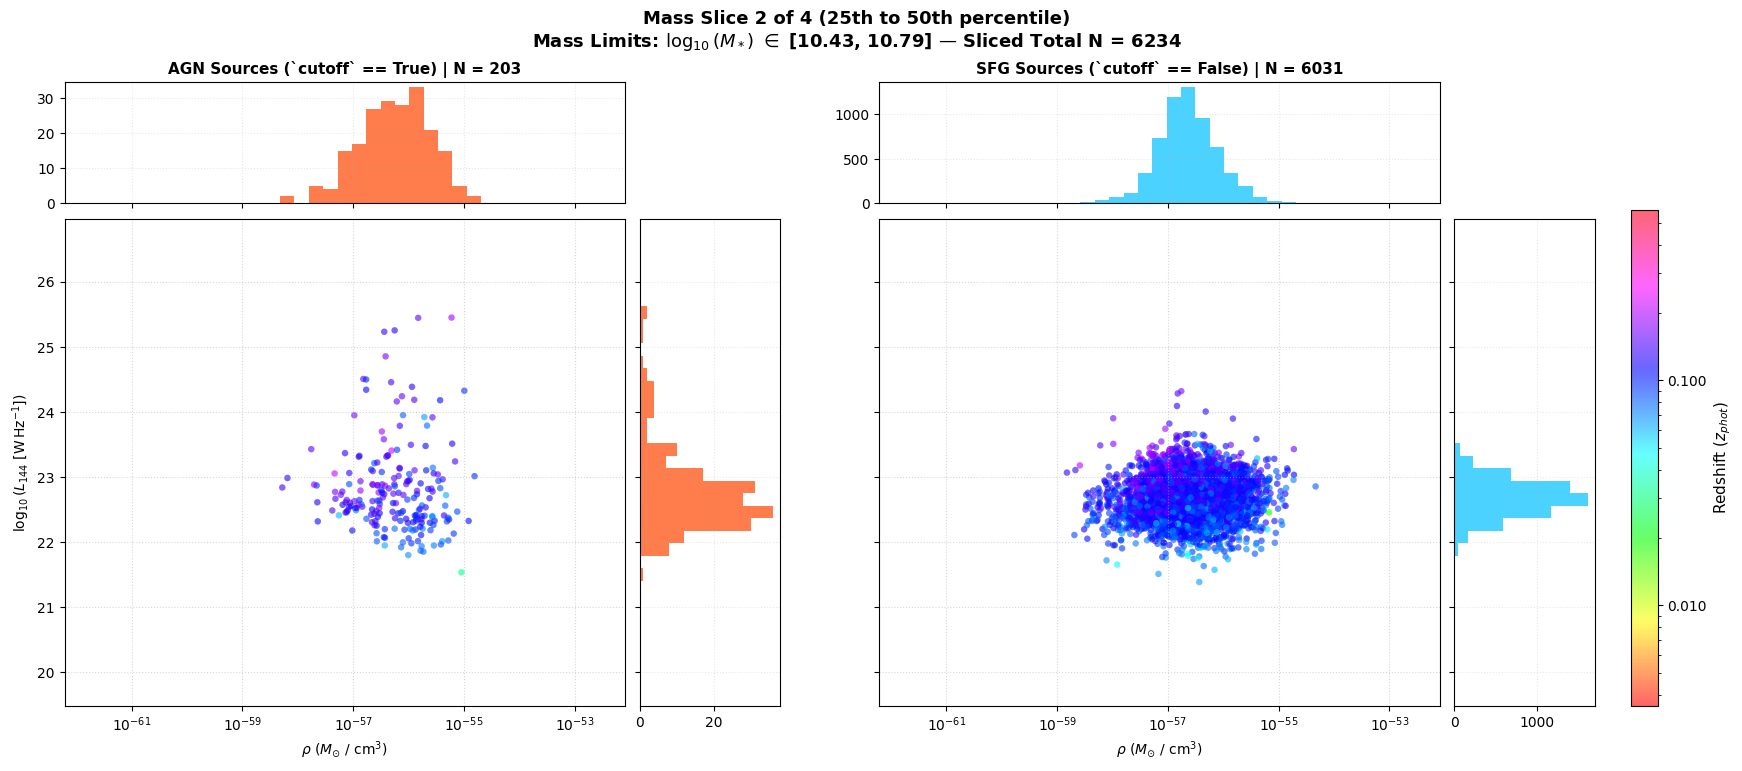

Saved: ./joint_scatters/joint_scatter_slice_3_logM_10p79_to_11p11.png


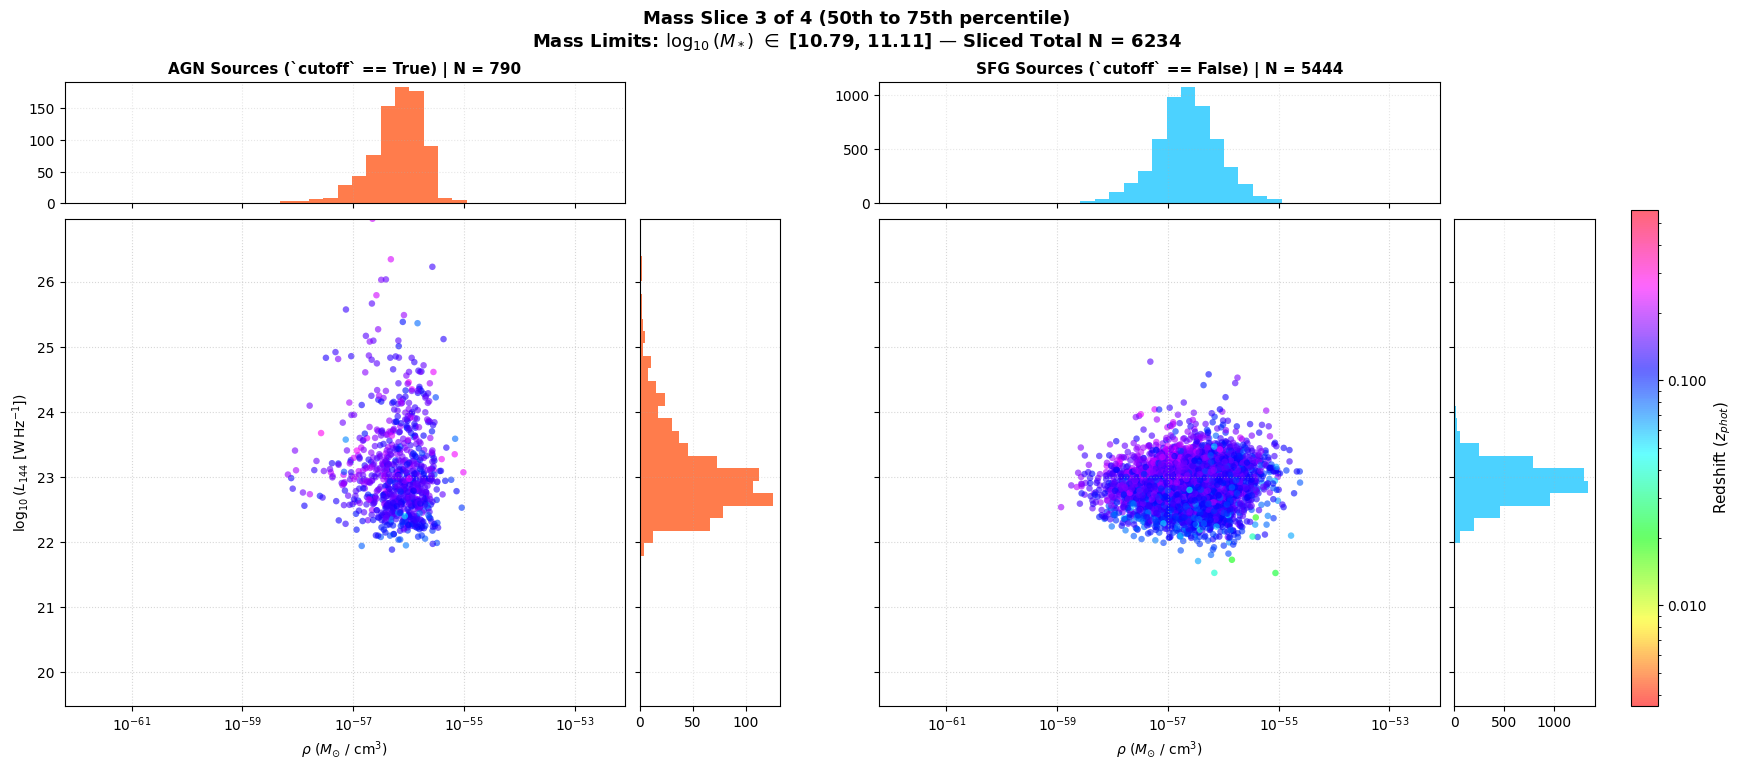

Saved: ./joint_scatters/joint_scatter_slice_4_logM_11p11_to_12p10.png


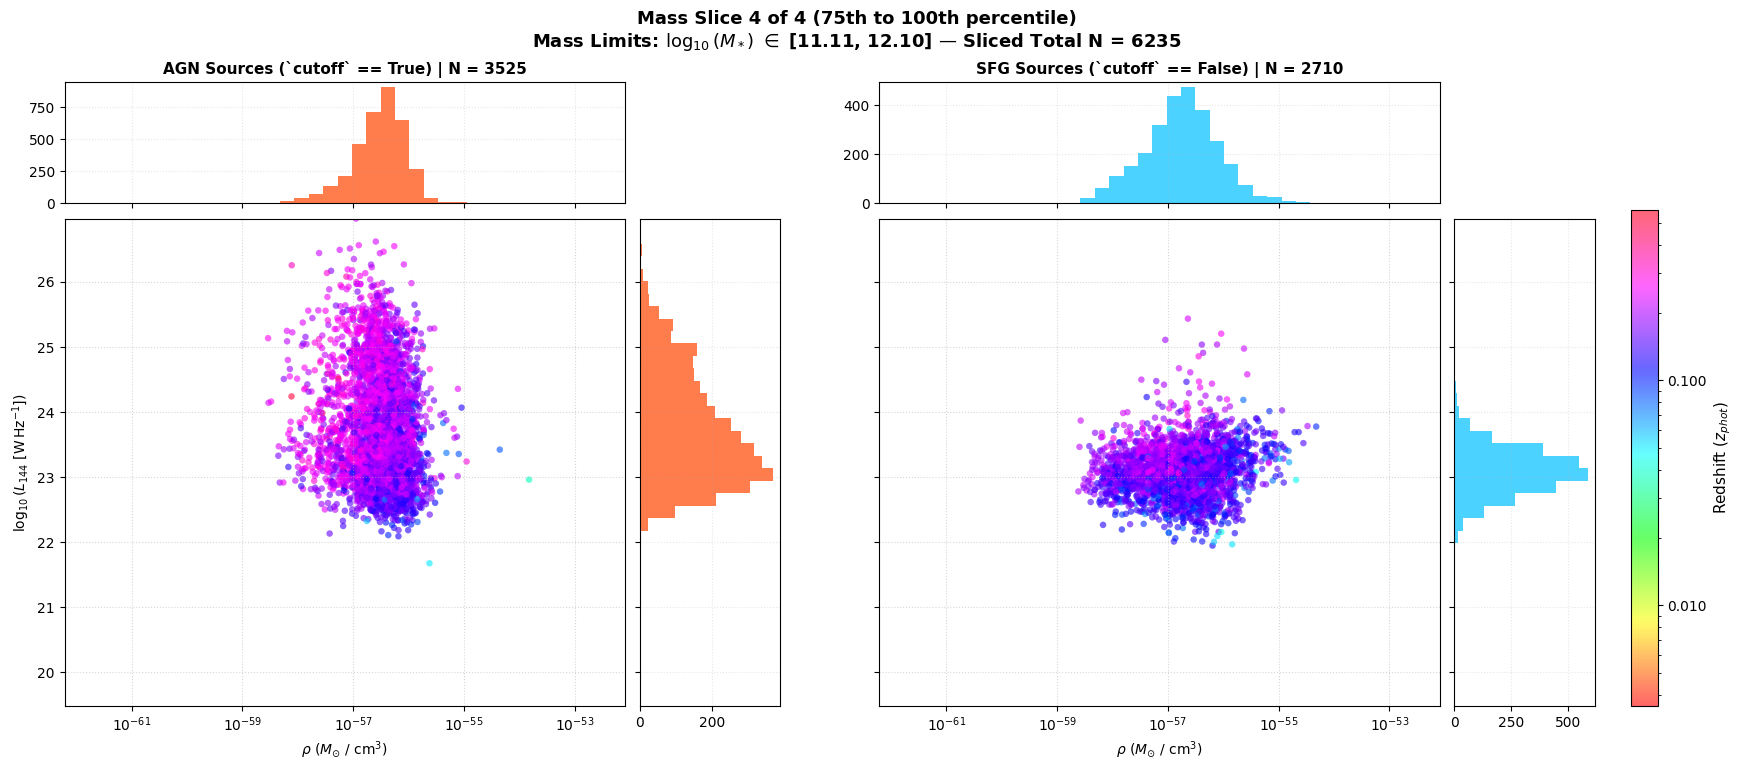

In [84]:
# Save files automatically to a new subdirectory named 'joint_scatters'
plot_scatter_marginal_hist_by_source_type(cut_data, num_slices=4, save_dir='./joint_scatters')

# Extra Plots

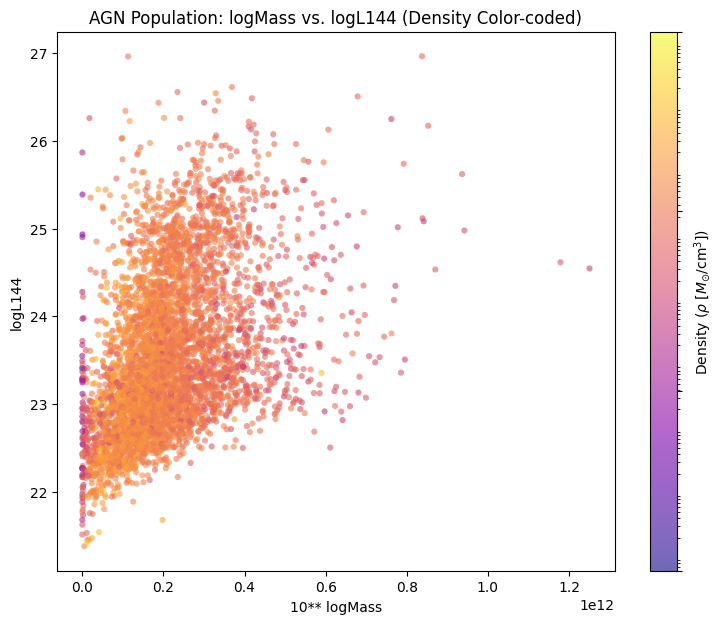

In [26]:
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
import numpy as np

def mass_actual_zscale_plot_DEV(data_table, p1, p2):
    dev_data = data_table
    
    # 2. Filter out NaNs for rho, p1, and p2 to ensure clean plotting
    nan_mask = ~np.isnan(dev_data[p1]) & ~np.isnan(dev_data[p2]) & ~np.isnan(dev_data['rho'])
    plot_data = dev_data[nan_mask]
    
    fig, ax = plt.subplots(figsize=(9, 7))
    
    # Define a LogNorm dynamically based on the min and max density values present
    rho_min = plot_data['rho'].min()
    rho_max = plot_data['rho'].max()
    norm_rho = mcolors.LogNorm(vmin=rho_min, vmax=rho_max)
    
    sc = ax.scatter(
        10 ** plot_data[p1],        # plot actual mass 
        plot_data[p2], 
        c=plot_data['rho'],         # Color grading based on density (rho)
        norm=norm_rho,
        cmap='plasma',             # 'viridis' or 'plasma' provide excellent contrast for density
        alpha=0.6, 
        s=20,
        edgecolors='none'
    )
    
    # 5. Add labels and title
    ax.set_xlabel(f"10** {p1}")
    ax.set_ylabel(p2)
    ax.set_title(f'AGN Population: {p1} vs. {p2} (Density Color-coded)')

    # --- Ticker settings for density (rho) ---
    # Create 4 cleanly spaced logarithmic tick marks from the min exponent to the max exponent
    log_min = np.log10(rho_min)
    log_max = np.log10(rho_max)
    custom_ticks = np.logspace(log_min, log_max, num=4)
    
    cbar = plt.colorbar(sc, ticks=custom_ticks) 
    
    # Use LogFormatterMathtext so tiny floats look like 10^{-65} instead of 0.000...
    cbar.ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext())
    
    # Ensure minor ticks don't overlap or clutter the clean log scale
    cbar.ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    # ----------------------------------------

    cbar.set_label('Density ($\\rho$ [$M_{\\odot}/\\text{cm}^3$])')
    
    # Save with a descriptive filename reflecting the density coding change
    plt.savefig("first_draft_plots/mass_logL144_density_coded")
    plt.show()

# Execution
mass_actual_zscale_plot_DEV(excess_cut_data, 'logMass', 'logL144')

Successfully loaded 40476 sources from disk.


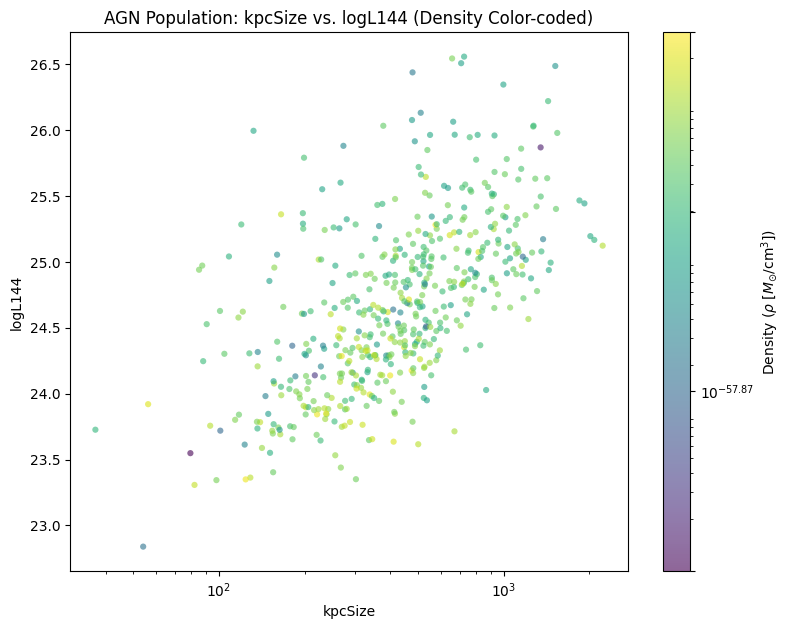

In [26]:
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
import numpy as np

def zscale_rho_logL144(data_table, p1, p2):
    dev_data = data_table
    
    # 2. Filter out NaNs for p1, p2, AND rho to ensure clean plotting
    nan_mask = ~np.isnan(dev_data[p1]) & ~np.isnan(dev_data[p2]) & ~np.isnan(dev_data['rho'])
    plot_data = dev_data[nan_mask]
    
    fig, ax = plt.subplots(figsize=(9, 7))
    ax.set_xscale('log')
    
    # Define a LogNorm dynamically based on the min and max density values present
    rho_min = plot_data['rho'].min()
    rho_max = plot_data['rho'].max()
    norm_rho = mcolors.LogNorm(vmin=rho_min, vmax=rho_max)
    
    sc = ax.scatter(
        plot_data[p1], 
        plot_data[p2], 
        c=plot_data['rho'],         # Color grading changed to density (rho)
        norm=norm_rho,
        cmap='viridis',             # 'viridis' or 'plasma' works great for continuous density mapping
        alpha=0.6, 
        s=20,
        edgecolors='none'
    )
    
    # 5. Add labels and title
    ax.set_xlabel(p1)
    ax.set_ylabel(p2)
    ax.set_title(f'AGN Population: {p1} vs. {p2} (Density Color-coded)')

    # --- Ticker settings for density (rho) tickmarks ---
    # Create 4 evenly-spaced logarithmic ticks from min density to max density
    log_min = np.log10(rho_min)
    log_max = np.log10(rho_max)
    custom_ticks = np.logspace(log_min, log_max, num=4)
    
    cbar = plt.colorbar(sc, ticks=custom_ticks) 
    
    # Use LogFormatterMathtext so tiny floats print like 10^{-64} instead of 0.000...
    cbar.ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext())
    
    # Ensure minor ticks don't clutter the color bar
    cbar.ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    # ---------------------------------------------------

    cbar.set_label('Density ($\\rho$ [$M_{\\odot}/\\text{cm}^3$])')
    
    # Adjusted filename to match the new plot style
    plt.savefig("first_draft_plots/kpcSize_logL144_density_coded")
    plt.show()

# Execution
cut_data = load_fits_table("cutoff_table.fits")
excess_cut_data = excess_radio_filter(cut_data)
zscale_rho_logL144(excess_cut_data, 'kpcSize', 'logL144')

/home/carles-fonseca-mauri/my_jupyter_project/myenv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4786: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  arr.partition(


Successfully loaded 40476 sources from disk.


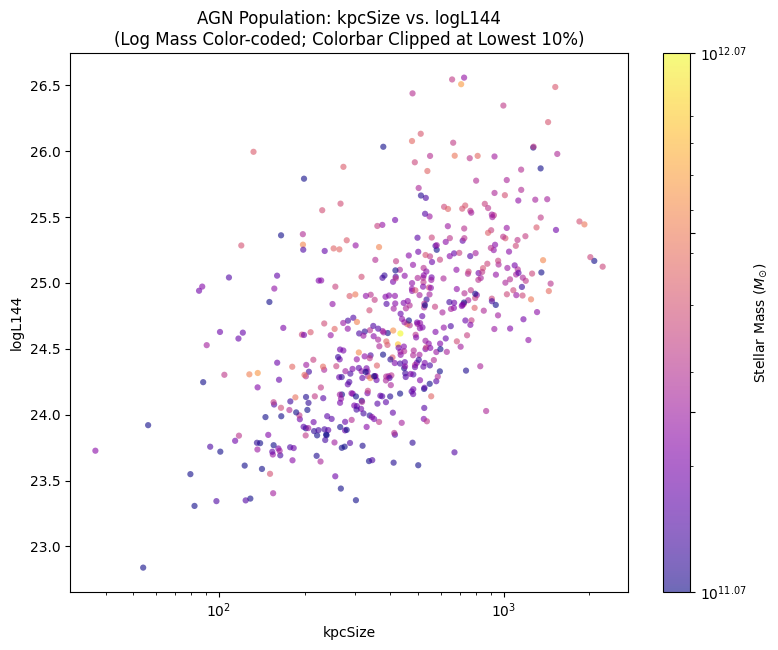

In [38]:
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
import numpy as np

def zscale_mass_logL144_clipped(data_table, p1, p2):
    dev_data = data_table
    
    # 1. Filter out NaNs for p1, p2, AND logMass to ensure clean plotting
    nan_mask = ~np.isnan(dev_data[p1]) & ~np.isnan(dev_data[p2]) & ~np.isnan(dev_data['logMass'])
    plot_data = dev_data[nan_mask]
    
    fig, ax = plt.subplots(figsize=(9, 7))
    ax.set_xscale('log')
    
    # 2. Calculate actual physical masses for all points
    actual_masses = 10 ** plot_data['logMass']
    
    # 3. Determine the 10th percentile threshold from the logMass values,
    # then convert it to its physical mass equivalent for the colorbar scale
    log_mass_threshold = np.percentile(plot_data['logMass'], 10)
    mass_threshold_physical = 10 ** log_mass_threshold
    mass_max = actual_masses.max()
    
    # 4. Define the LogNorm mapping. 
    # vmin is set to the 10th percentile cutoff instead of the absolute minimum.
    norm_mass = mcolors.LogNorm(vmin=mass_threshold_physical, vmax=mass_max)
    
    # 5. Create the scatter plot (all points are plotted)
    sc = ax.scatter(
        plot_data[p1], 
        plot_data[p2], 
        c=actual_masses,            # Color grading by absolute physical stellar mass
        norm=norm_mass,             # Logarithmic mapping with clipped lower bound
        cmap='plasma',              
        alpha=0.6, 
        s=20,
        edgecolors='none'
    )
    
    # 6. Add labels and title
    ax.set_xlabel(p1)
    ax.set_ylabel(p2)
    ax.set_title(f'AGN Population: {p1} vs. {p2}\n(Log Mass Color-coded; Colorbar Clipped at Lowest 10%)')

    # --- Ticker settings for the log-scaled Mass colorbar ---
    # Create 4 evenly-spaced logarithmic ticks from the 10th percentile bound up to the max mass
    log_min_bound = np.log10(mass_threshold_physical)
    log_max_bound = np.log10(mass_max)
    custom_ticks = np.logspace(log_min_bound, log_max_bound, num=4)
    
    cbar = plt.colorbar(sc, ticks=custom_ticks) 
    
    # Use LogFormatterMathtext to print beautifully formatted exponents (e.g., 10^{11})
    cbar.ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext())
    
    # Clear minor tick clutter on the log scale
    cbar.ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    # --------------------------------------------------------

    cbar.set_label(r'Stellar Mass ($M_{\odot}$)')
    
    # Save the plot with a clear descriptive name
    plt.savefig("first_draft_plots/kpcSize_logL144_log_mass_colorbar_clipped")
    plt.show()

# Execution
cut_data = load_fits_table("cutoff_table.fits")
excess_cut_data = excess_radio_filter(cut_data)
zscale_mass_logL144_clipped(excess_cut_data, 'kpcSize', 'logL144')

Successfully loaded 40476 sources from disk.


NameError: name 'mass_threshold_physical' is not defined

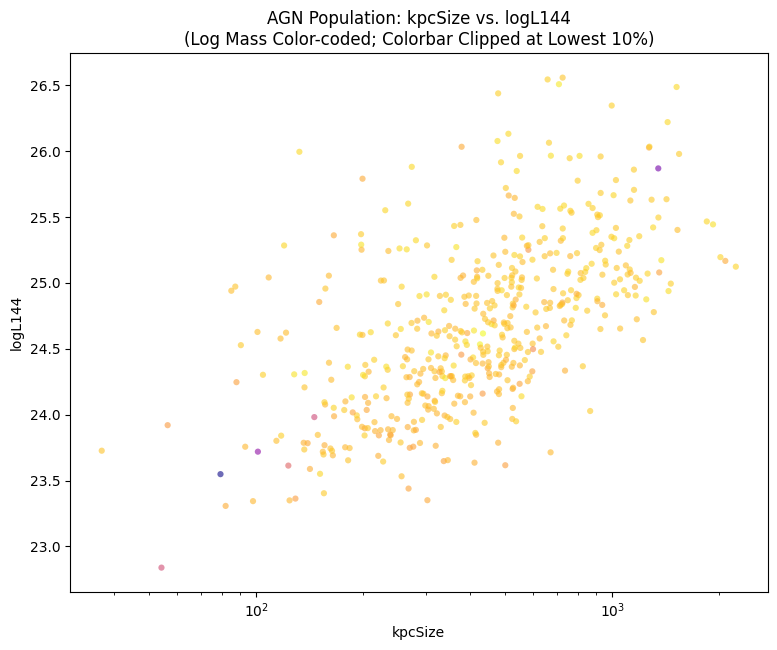

In [20]:
### WITHOUT CLIPPING: 
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
import numpy as np

def zscale_mass_logL144_clipped(data_table, p1, p2):
    dev_data = data_table
    
    # 1. Filter out NaNs for p1, p2, AND logMass to ensure clean plotting
    nan_mask = ~np.isnan(dev_data[p1]) & ~np.isnan(dev_data[p2]) & ~np.isnan(dev_data['logMass'])
    plot_data = dev_data[nan_mask]
    
    fig, ax = plt.subplots(figsize=(9, 7))
    ax.set_xscale('log')
    
    # 2. Calculate actual physical masses for all points
    log_mass = plot_data['logMass']
    
    # 3. Determine the 10th percentile threshold from the logMass values,
    # then convert it to its physical mass equivalent for the colorbar scale
    
    # 4. Define the LogNorm mapping. 
    # vmin is set to the 10th percentile cutoff instead of the absolute minimum.
    norm_mass = mcolors.LogNorm()
    
    # 5. Create the scatter plot (all points are plotted)
    sc = ax.scatter(
        plot_data[p1], 
        plot_data[p2], 
        c=log_mass,            # Color grading by absolute physical stellar mass
        norm=norm_mass,             # Logarithmic mapping with clipped lower bound
        cmap='plasma',              
        alpha=0.6, 
        s=20,
        edgecolors='none'
    )
    
    # 6. Add labels and title
    ax.set_xlabel(p1)
    ax.set_ylabel(p2)
    ax.set_title(f'AGN Population: {p1} vs. {p2}\n(Log Mass Color-coded; Colorbar Clipped at Lowest 10%)')

    # --- Ticker settings for the log-scaled Mass colorbar ---
    # Create 4 evenly-spaced logarithmic ticks from the 10th percentile bound up to the max mass
    log_min_bound = np.log10(mass_threshold_physical)
    log_max_bound = np.log10(mass_max)
    custom_ticks = np.logspace(log_min_bound, log_max_bound, num=4)
    
    cbar = plt.colorbar(sc, ticks=custom_ticks) 
    
    # Use LogFormatterMathtext to print beautifully formatted exponents (e.g., 10^{11})
    cbar.ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext())
    
    # Clear minor tick clutter on the log scale
    cbar.ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    # --------------------------------------------------------

    cbar.set_label(r'Stellar Mass ($M_{\odot}$)')
    
    # Save the plot with a clear descriptive name
    plt.savefig("first_draft_plots/kpcSize_logL144_log_mass_colorbar_clipped")
    plt.show()

# Execution
cut_data = load_fits_table("cutoff_table.fits")
excess_cut_data = excess_radio_filter(cut_data)
zscale_mass_logL144_clipped(excess_cut_data, 'kpcSize', 'logL144')

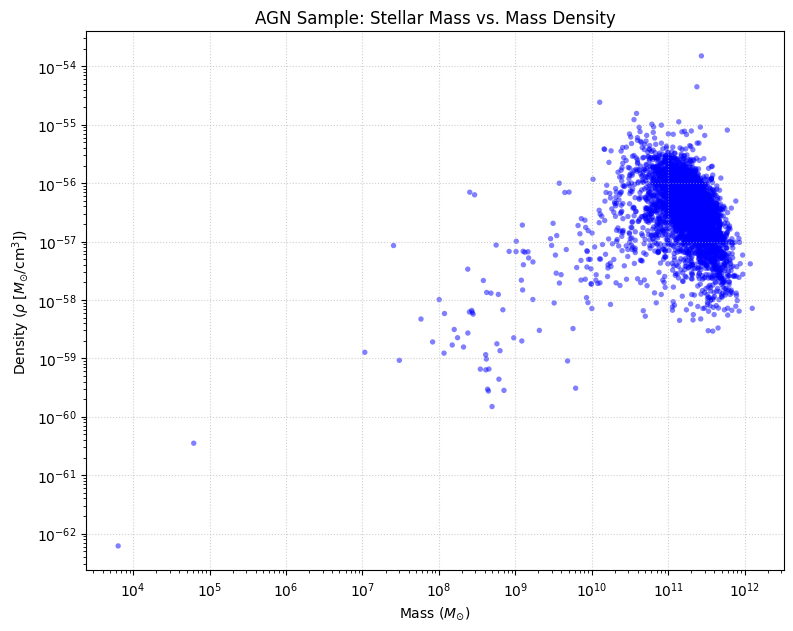

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

def plot_mass_vs_density(data_table):
    dev_data = data_table
    
    # Filter out NaNs for logMass and rho to ensure clean plotting
    nan_mask = ~np.isnan(dev_data['logMass']) & ~np.isnan(dev_data['rho'])
    plot_data = dev_data[nan_mask]
    
    fig, ax = plt.subplots(figsize=(9, 7))
    
    # 1. Plot the actual values (Base 10 Mass on X, Density on Y)
    # Both are placed on log scales to cleanly isolate the vast exponential separation
    ax.scatter(
        10 ** plot_data['logMass'],    # Convert dex back to actual Solar Masses
        plot_data['rho'],              # Absolute density (M_sun / cm^3)
        color='blue',                  # Single diagnostic tint for simplicity
        alpha=0.5, 
        s=15,
        edgecolors='none'
    )
    
    # 2. Convert standard scatter distribution into Log-Log scaling
    ax.set_xscale('log')
    ax.set_yscale('log')
    
    # 3. Handle tiny density axis dimensions using MathText formatting
    ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext())
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    
    # 4. Standard log ticks for the X-axis (Mass)
    ax.xaxis.set_major_formatter(mticker.LogFormatterMathtext())
    
    # 5. Add labels and title
    ax.set_xlabel(r'Mass ($M_{\odot}$)')
    ax.set_ylabel(r'Density ($\rho$ [$M_{\odot}/\text{cm}^3$])')
    ax.set_title('AGN Sample: Stellar Mass vs. Mass Density')
    
    ax.grid(True, which="major", ls=":", alpha=0.6)
    
    # Save the output configuration
    plt.savefig("first_draft_plots/mass_vs_density_diagnostic")
    plt.show()

# Execution
plot_mass_vs_density(excess_cut_data)